# Phase 3: Pair Selection (Correlation + Cointegration)

In [2]:
import json
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

DATA_DIR = Path('../data')
OUT_DIR  = Path('../outputs')

train = pd.read_csv(DATA_DIR / 'prices_train.csv', index_col=0, parse_dates=True)
with open(DATA_DIR / 'sectors.json', 'r') as f:
    sectors = json.load(f)

print(f'Train shape: {train.shape}')

Train shape: (1728, 22)


In [5]:
def estimate_beta(y: pd.Series, x: pd.Series) -> float:
    X = sm.add_constant(x.values)
    model = sm.OLS(y.values, X).fit()
    return float(model.params[1])


def process_pair(sector: str, a: str, b: str, train: pd.DataFrame):
    """Test one pair and return results dict, or None if filtered out."""
    corr = train[[a, b]].corr().iloc[0, 1]
    if corr < 0.80:
        return None

    joined   = pd.concat([train[a], train[b]], axis=1).dropna()
    s1j, s2j = joined.iloc[:, 0], joined.iloc[:, 1]

    coint_stat, coint_pval, _ = coint(s1j, s2j)
    beta         = estimate_beta(s1j, s2j)
    spread       = s1j - beta * s2j
    spread_adf_p = adfuller(spread, autolag='AIC')[1]

    return {
        'sector'           : sector,
        'stock_a'          : a,
        'stock_b'          : b,
        'corr_train'       : float(corr),
        'coint_stat'       : float(coint_stat),
        'coint_pvalue'     : float(coint_pval),
        'spread_adf_pvalue': float(spread_adf_p),
        'beta_a_on_b'      : float(beta),
    }

In [12]:
# Build all candidate (sector, a, b) triples first
candidates = [
    (sector, a, b)
    for sector, tickers in sectors.items()
    for a, b in combinations([t for t in tickers if t in train.columns], 2)
]

print(f'Total pairs to test: {len(candidates)}')

# Parallel execution — n_jobs=-1 uses all CPU cores
# Progress bar shows pair-by-pair progress
try:
    iterator = tqdm(candidates, desc='Testing pairs')
except Exception:
    # Fallback when ipywidgets/IProgress is unavailable
    iterator = candidates

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(process_pair)(sector, a, b, train)
    for sector, a, b in iterator
)

rows = [r for r in results if r is not None]

pairs_df = pd.DataFrame(rows)
if pairs_df.empty:
    raise ValueError('No candidate pairs found. Try lower corr threshold.')

pairs_df['cointegrated_5pct'] = pairs_df['coint_pvalue'] < 0.05
pairs_df = pairs_df.sort_values(
    ['cointegrated_5pct', 'coint_pvalue', 'corr_train'],
    ascending=[False, True, False]
)

display(pairs_df.head(20))
print(f'Total candidate pairs : {len(pairs_df)}')
print(f'Cointegrated (5%)     : {pairs_df.cointegrated_5pct.sum()}')

Exception ignored in: <function tqdm.__del__ at 0x00000285C2C89A80>
Traceback (most recent call last):
  File "c:\projects\Pair-Trading-Project\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\projects\Pair-Trading-Project\.venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


Total pairs to test: 52


,sector,stock_a,stock_b,corr_train,coint_stat,coint_pvalue,spread_adf_pvalue,beta_a_on_b,cointegrated_5pct
20,Auto,HEROMOTOCO.NS,EICHERMOT.NS,0.878887,-4.679344,0.000612,0.000093,0.699395,True
1,Banking,HDFCBANK.NS,KOTAKBANK.NS,0.983589,-4.612719,0.000795,0.000123,1.893697,True
11,IT,INFY.NS,HCLTECH.NS,0.983530,-3.984791,0.007548,0.001499,1.675661,True
19,IT,TECHM.NS,MPHASIS.NS,0.959931,-3.059206,0.096794,0.029773,0.374164,False
14,IT,WIPRO.NS,HCLTECH.NS,0.962673,-3.039752,0.101056,0.031423,0.285786,False
22,Energy,ONGC.NS,COALINDIA.NS,0.802749,-2.951530,0.122181,0.039781,0.637882,False
10,IT,INFY.NS,WIPRO.NS,0.966200,-2.820908,0.159123,0.055409,5.545020,False
15,IT,WIPRO.NS,TECHM.NS,0.951892,-2.755368,0.180299,0.065071,0.225990,False
17,IT,HCLTECH.NS,TECHM.NS,0.946733,-2.677272,0.207859,0.078201,0.757122,False
0,Banking,HDFCBANK.NS,ICICIBANK.NS,0.909887,-2.543819,0.260093,0.105227,1.027814,False


Total candidate pairs : 23
Cointegrated (5%)     : 3


In [10]:
# Select top pairs for strategy building
top_pairs = pairs_df[pairs_df['cointegrated_5pct']].groupby('sector').head(3).reset_index(drop=True)
if top_pairs.empty:
    top_pairs = pairs_df.groupby('sector').head(1).reset_index(drop=True)

display(top_pairs)

pairs_df.to_csv(DATA_DIR / 'all_candidate_pairs.csv', index=False)
top_pairs.to_csv(DATA_DIR / 'selected_pairs.csv', index=False)
print('Saved: ../data/all_candidate_pairs.csv')
print('Saved: ../data/selected_pairs.csv')

,sector,stock_a,stock_b,corr_train,coint_stat,coint_pvalue,spread_adf_pvalue,beta_a_on_b,cointegrated_5pct
0,Auto,HEROMOTOCO.NS,EICHERMOT.NS,0.878887,-4.679344,0.000612,0.000093,0.699395,True
1,Banking,HDFCBANK.NS,KOTAKBANK.NS,0.983589,-4.612719,0.000795,0.000123,1.893697,True
2,IT,INFY.NS,HCLTECH.NS,0.983530,-3.984791,0.007548,0.001499,1.675661,True


Saved: ../data/all_candidate_pairs.csv
Saved: ../data/selected_pairs.csv


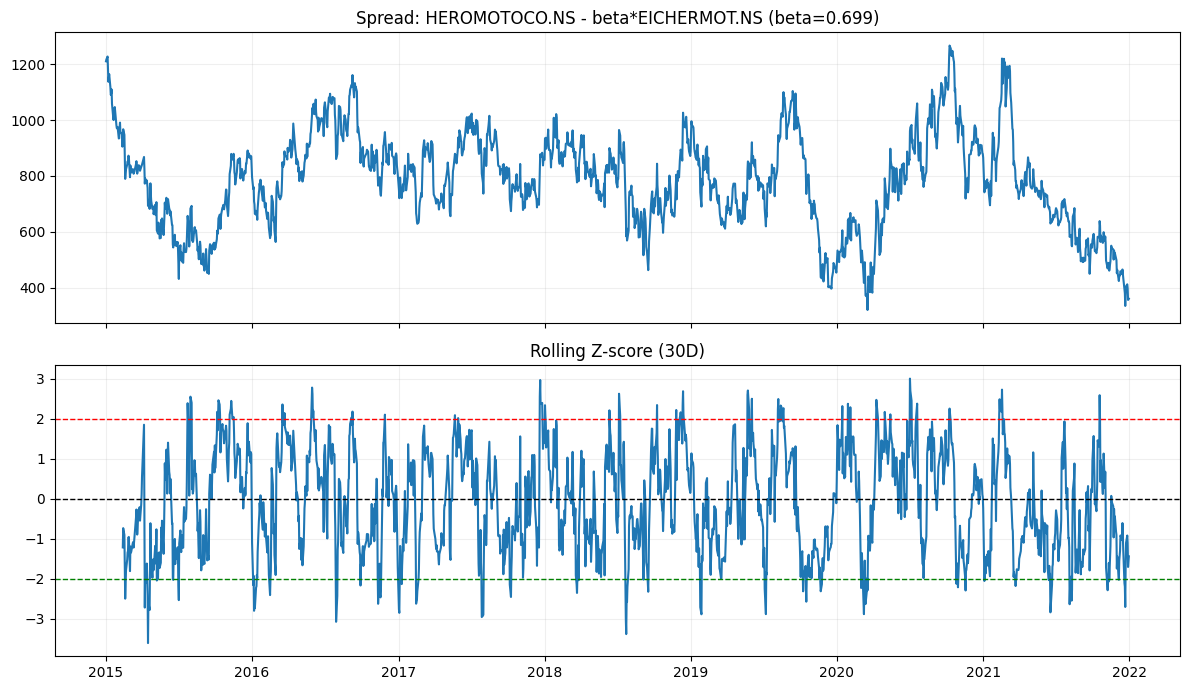

Saved: ../outputs/04_best_pair_spread_zscore.png


In [11]:
import matplotlib.pyplot as plt

best   = top_pairs.iloc[0]
a, b   = best['stock_a'], best['stock_b']
beta   = float(best['beta_a_on_b'])
spread = train[a] - beta * train[b]
z      = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(spread.index, spread.values)
axes[0].set_title(f'Spread: {a} - beta*{b} (beta={beta:.3f})')
axes[0].grid(alpha=0.2)

axes[1].plot(z.index, z.values)
axes[1].axhline( 2, color='r', ls='--', lw=1)
axes[1].axhline(-2, color='g', ls='--', lw=1)
axes[1].axhline( 0, color='black', ls='--', lw=1)
axes[1].set_title('Rolling Z-score (30D)')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_best_pair_spread_zscore.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/04_best_pair_spread_zscore.png')